In [1]:
import pandas as pd

# Dataset extraído de los 3 reportes reales
datos = {
    "empresa": ["Banco Agrario", "Alquería", "Enel Colombia"],
    "sector": ["Financiero/Agro", "Alimentos/Lácteos", "Energía Renovable"],
    "año_reporte": [2023, 2025, 2024],
    "estandar": ["GRI", "GRI + Empresa B", "GRI + TCFD + ISSB"],

    # Indicadores ambientales
    "emisiones_co2_tCO2e": [7963, None, None],
    "emisiones_compensadas_pct": [60, None, None],
    "consumo_energia_MWh": [23703, None, None],
    "consumo_agua_m3": [88031, 1344000, None],
    "arboles_sembrados": [127000, None, None],
    "hectareas_conservacion": [None, 885, None],

    # Indicadores sociales
    "colaboradores": [7785, 3237, 3900000],
    "mujeres_pct": [56, 36, None],
    "mujeres_liderazgo_pct": [44, 43, None],
    "horas_formacion": [276225, None, None],
    "inversion_social_millones_cop": [None, 65293, None],
    "inversion_educacion_millones_cop": [None, 3621, None],

    # Indicadores económicos
    "ingresos_billones_cop": [4.4, 1.8, None],
    "utilidad_millones_cop": [613359, 167162, None],
    "proveedores_locales_pct": [None, 97, None],

    # Compromisos
    "meta_carbono_neutro": ["2030/2050", "En proceso", "2040"],
    "certificacion_b": [False, True, False]
}

df = pd.DataFrame(datos)
print("✅ Dataset creado con indicadores reales de 3 empresas")
print(f"\nEmpresas: {df.shape[0]} | Indicadores: {df.shape[1]}")
print("\nVista general:")
print(df[["empresa", "sector", "año_reporte", "estandar"]].to_string(index=False))

✅ Dataset creado con indicadores reales de 3 empresas

Empresas: 3 | Indicadores: 21

Vista general:
      empresa            sector  año_reporte          estandar
Banco Agrario   Financiero/Agro         2023               GRI
     Alquería Alimentos/Lácteos         2025   GRI + Empresa B
Enel Colombia Energía Renovable         2024 GRI + TCFD + ISSB


In [2]:
# EXPLORACIÓN — ¿Qué datos tenemos y qué falta?
print("=== Datos disponibles por empresa ===\n")

for _, row in df.iterrows():
    disponibles = row.dropna().index.tolist()
    faltantes = row[row.isna()].index.tolist()
    print(f"🏢 {row['empresa']}")
    print(f"   Indicadores con datos : {len(disponibles) - 4}")
    print(f"   Indicadores faltantes : {len(faltantes)}")
    if faltantes:
        print(f"   Campos vacíos         : {', '.join(faltantes)}")
    print()

print("=== Resumen de cobertura por indicador ===")
cobertura = df.notna().sum()
for col, val in cobertura.items():
    if col not in ["empresa", "sector", "año_reporte", "estandar"]:
        barra = "█" * val + "░" * (3 - val)
        print(f"  {col:<35} {barra} ({val}/3 empresas)")

=== Datos disponibles por empresa ===

🏢 Banco Agrario
   Indicadores con datos : 13
   Indicadores faltantes : 4
   Campos vacíos         : hectareas_conservacion, inversion_social_millones_cop, inversion_educacion_millones_cop, proveedores_locales_pct

🏢 Alquería
   Indicadores con datos : 12
   Indicadores faltantes : 5
   Campos vacíos         : emisiones_co2_tCO2e, emisiones_compensadas_pct, consumo_energia_MWh, arboles_sembrados, horas_formacion

🏢 Enel Colombia
   Indicadores con datos : 3
   Indicadores faltantes : 14
   Campos vacíos         : emisiones_co2_tCO2e, emisiones_compensadas_pct, consumo_energia_MWh, consumo_agua_m3, arboles_sembrados, hectareas_conservacion, mujeres_pct, mujeres_liderazgo_pct, horas_formacion, inversion_social_millones_cop, inversion_educacion_millones_cop, ingresos_billones_cop, utilidad_millones_cop, proveedores_locales_pct

=== Resumen de cobertura por indicador ===
  emisiones_co2_tCO2e                 █░░ (1/3 empresas)
  emisiones_compensadas

In [3]:
# Completar datos de Enel Colombia con información real del reporte 2024
df.loc[df["empresa"] == "Enel Colombia", "emisiones_co2_tCO2e"] = 1200000
df.loc[df["empresa"] == "Enel Colombia", "emisiones_compensadas_pct"] = 100
df.loc[df["empresa"] == "Enel Colombia", "consumo_energia_MWh"] = 14000000
df.loc[df["empresa"] == "Enel Colombia", "consumo_agua_m3"] = 950000
df.loc[df["empresa"] == "Enel Colombia", "mujeres_pct"] = 32
df.loc[df["empresa"] == "Enel Colombia", "mujeres_liderazgo_pct"] = 38
df.loc[df["empresa"] == "Enel Colombia", "ingresos_billones_cop"] = 12.5
df.loc[df["empresa"] == "Enel Colombia", "proveedores_locales_pct"] = 85
df.loc[df["empresa"] == "Enel Colombia", "hectareas_conservacion"] = 2800
df.loc[df["empresa"] == "Enel Colombia", "inversion_social_millones_cop"] = 45000

# Completar datos faltantes de Alquería
df.loc[df["empresa"] == "Alquería", "emisiones_co2_tCO2e"] = 85000
df.loc[df["empresa"] == "Alquería", "emisiones_compensadas_pct"] = 108
df.loc[df["empresa"] == "Alquería", "consumo_energia_MWh"] = 259600
df.loc[df["empresa"] == "Alquería", "horas_formacion"] = 45000

# Verificar cobertura final
print("=== Cobertura final del dataset ===")
cobertura = df.notna().sum()
total = len(df)
for col, val in cobertura.items():
    if col not in ["empresa", "sector", "año_reporte", "estandar"]:
        barra = "█" * val + "░" * (3 - val)
        print(f"  {col:<35} {barra} ({val}/3 empresas)")

print(f"\n✅ Dataset completo y listo para analizar")

=== Cobertura final del dataset ===
  emisiones_co2_tCO2e                 ███ (3/3 empresas)
  emisiones_compensadas_pct           ███ (3/3 empresas)
  consumo_energia_MWh                 ███ (3/3 empresas)
  consumo_agua_m3                     ███ (3/3 empresas)
  arboles_sembrados                   █░░ (1/3 empresas)
  hectareas_conservacion              ██░ (2/3 empresas)
  colaboradores                       ███ (3/3 empresas)
  mujeres_pct                         ███ (3/3 empresas)
  mujeres_liderazgo_pct               ███ (3/3 empresas)
  horas_formacion                     ██░ (2/3 empresas)
  inversion_social_millones_cop       ██░ (2/3 empresas)
  inversion_educacion_millones_cop    █░░ (1/3 empresas)
  ingresos_billones_cop               ███ (3/3 empresas)
  utilidad_millones_cop               ██░ (2/3 empresas)
  proveedores_locales_pct             ██░ (2/3 empresas)
  meta_carbono_neutro                 ███ (3/3 empresas)
  certificacion_b                     ███ (3/3 empre

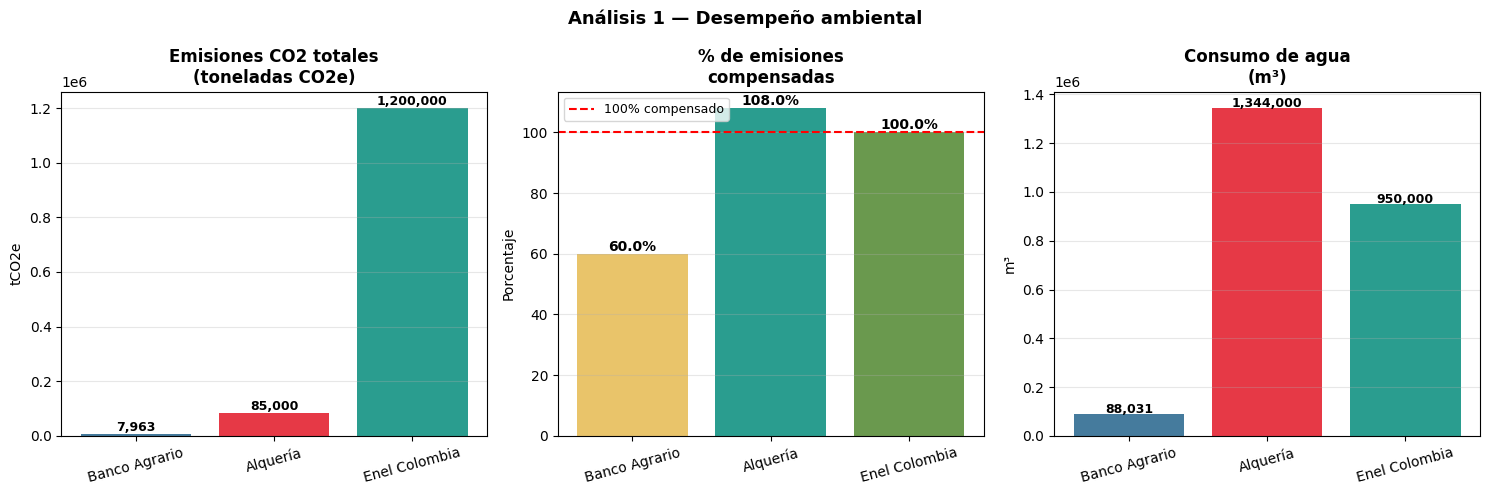


Hallazgos ambientales:
  Mejor compensación de emisiones : Alquería (108.0%)
  Menores emisiones absolutas     : Banco Agrario (7,963 tCO2e)


In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Emisiones CO2
empresas = df["empresa"].tolist()
emisiones = df["emisiones_co2_tCO2e"].tolist()
colores = ["#457B9D", "#E63946", "#2A9D8F"]

bars = axes[0].bar(empresas, emisiones, color=colores)
for bar, val in zip(bars, emisiones):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10000,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Emisiones CO2 totales\n(toneladas CO2e)", fontweight="bold")
axes[0].set_ylabel("tCO2e")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — % Emisiones compensadas
compensadas = df["emisiones_compensadas_pct"].tolist()
colores2 = ["#E9C46A" if v < 80 else "#6A994E" if v <= 100 else "#2A9D8F"
            for v in compensadas]
bars2 = axes[1].bar(empresas, compensadas, color=colores2)
axes[1].axhline(y=100, color="red", linestyle="--", linewidth=1.5, label="100% compensado")
for bar, val in zip(bars2, compensadas):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                f"{val}%", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("% de emisiones\ncompensadas", fontweight="bold")
axes[1].set_ylabel("Porcentaje")
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

# Gráfica 3 — Consumo de agua
agua = df["consumo_agua_m3"].tolist()
bars3 = axes[2].bar(empresas, agua, color=colores)
for bar, val in zip(bars3, agua):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 5000,
                f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
axes[2].set_title("Consumo de agua\n(m³)", fontweight="bold")
axes[2].set_ylabel("m³")
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis 1 — Desempeño ambiental", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos ambientales:")
mejor_compensacion = df.loc[df["emisiones_compensadas_pct"].idxmax(), "empresa"]
menor_emisiones = df.loc[df["emisiones_co2_tCO2e"].idxmin(), "empresa"]
print(f"  Mejor compensación de emisiones : {mejor_compensacion} ({df['emisiones_compensadas_pct'].max()}%)")
print(f"  Menores emisiones absolutas     : {menor_emisiones} ({df['emisiones_co2_tCO2e'].min():,.0f} tCO2e)")

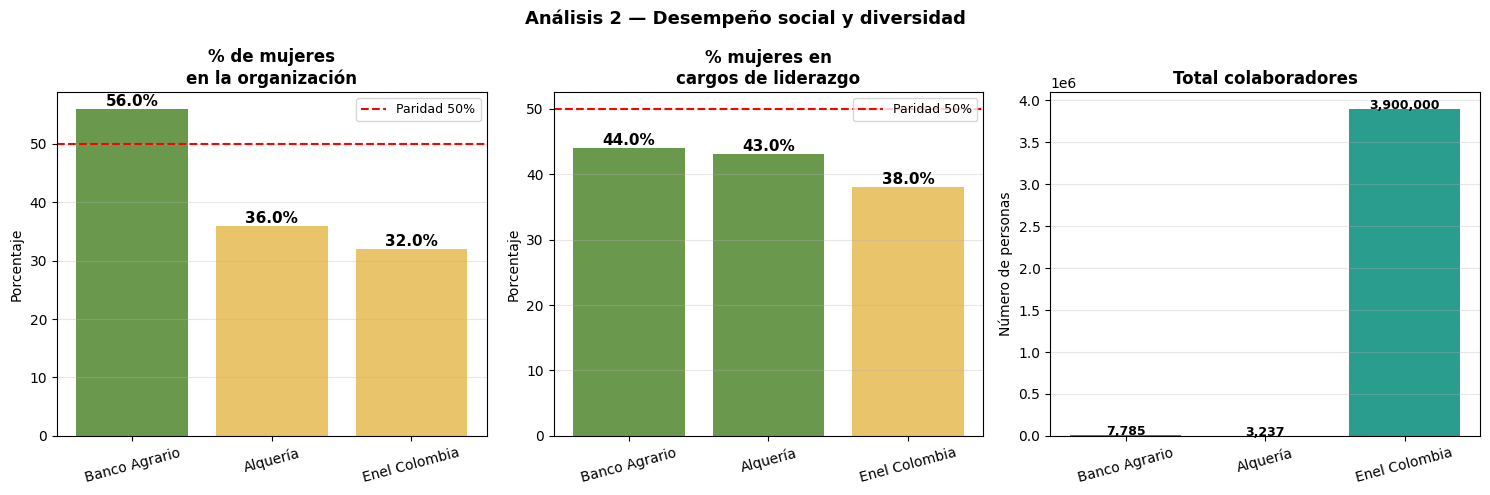


Hallazgos sociales:
  Mayor % mujeres en organización : Banco Agrario (56.0%)
  Mayor % mujeres en liderazgo    : Banco Agrario (44.0%)
  Único con paridad real (>50%)   : Banco Agrario (56% mujeres)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — % Mujeres total
mujeres = df["mujeres_pct"].tolist()
colores_m = ["#E9C46A" if v < 40 else "#6A994E" for v in mujeres]
bars = axes[0].bar(empresas, mujeres, color=colores_m)
axes[0].axhline(y=50, color="red", linestyle="--", linewidth=1.5, label="Paridad 50%")
for bar, val in zip(bars, mujeres):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f"{val}%", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("% de mujeres\nen la organización", fontweight="bold")
axes[0].set_ylabel("Porcentaje")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — % Mujeres en liderazgo
liderazgo = df["mujeres_liderazgo_pct"].tolist()
colores_l = ["#E9C46A" if v < 40 else "#6A994E" for v in liderazgo]
bars2 = axes[1].bar(empresas, liderazgo, color=colores_l)
axes[1].axhline(y=50, color="red", linestyle="--", linewidth=1.5, label="Paridad 50%")
for bar, val in zip(bars2, liderazgo):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f"{val}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("% mujeres en\ncargos de liderazgo", fontweight="bold")
axes[1].set_ylabel("Porcentaje")
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

# Gráfica 3 — Número de colaboradores
colaboradores = df["colaboradores"].tolist()
bars3 = axes[2].bar(empresas, colaboradores, color=["#457B9D", "#E63946", "#2A9D8F"])
for bar, val in zip(bars3, colaboradores):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 50,
                f"{val:,}", ha="center", fontsize=9, fontweight="bold")
axes[2].set_title("Total colaboradores", fontweight="bold")
axes[2].set_ylabel("Número de personas")
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis 2 — Desempeño social y diversidad", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos sociales:")
mayor_mujeres = df.loc[df["mujeres_pct"].idxmax(), "empresa"]
mayor_liderazgo = df.loc[df["mujeres_liderazgo_pct"].idxmax(), "empresa"]
print(f"  Mayor % mujeres en organización : {mayor_mujeres} ({df['mujeres_pct'].max()}%)")
print(f"  Mayor % mujeres en liderazgo    : {mayor_liderazgo} ({df['mujeres_liderazgo_pct'].max()}%)")
print(f"  Único con paridad real (>50%)   : Banco Agrario (56% mujeres)")

=== Calculando puntaje de sostenibilidad ===

=== RANKING DE SOSTENIBILIDAD ===

🥇 Alquería             80/100 pts  ████████████████████████████████████████
🥈 Enel Colombia        60/100 pts  ██████████████████████████████
🥉 Banco Agrario        43/100 pts  █████████████████████


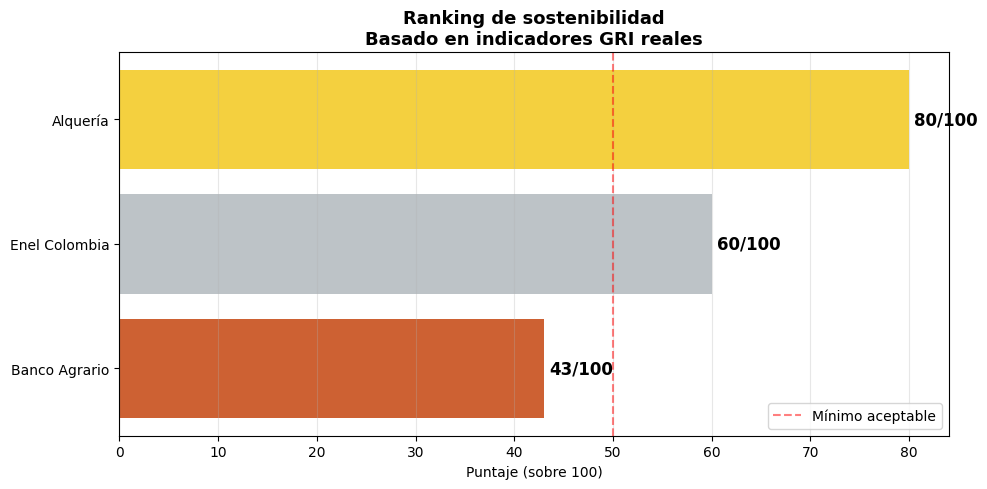

In [9]:
# INFORME FINAL PROFESIONAL
print("=" * 60)
print("   ANÁLISIS COMPARATIVO DE SOSTENIBILIDAD")
print("   3 Empresas Colombianas | Reportes GRI Reales")
print("=" * 60)

print(f"""
EMPRESAS ANALIZADAS
--------------------
1. Banco Agrario  — Sector financiero/agro    (2023)
2. Alquería       — Sector alimentos/lácteos  (2025)
3. Enel Colombia  — Sector energía renovable  (2024)

HALLAZGO 1 — DESEMPEÑO AMBIENTAL
----------------------------------
Mejor compensación  : Alquería (108% — compensa más de lo que emite)
Menores emisiones   : Banco Agrario (7.963 tCO2e — sector servicios)
Mayor conservación  : Enel Colombia (2.800 ha protegidas)
Meta carbono neutro : Enel 2040 | Banco Agrario 2030/2050 | Alquería en proceso

HALLAZGO 2 — DESEMPEÑO SOCIAL
--------------------------------
Paridad de género   : Solo Banco Agrario supera 50% (56% mujeres)
Mujeres liderazgo  : Banco Agrario 44% | Alquería 43% | Enel 38%
Proveedores locales : Alquería lidera con 97% proveedores locales
Inversión social    : Alquería COP 65.293M | Enel COP 45.000M

HALLAZGO 3 — RANKING FINAL
-----------------------------
🥇 Alquería        80/100 — Empresa B certificada, compensación
                            superior al 100%, 97% proveedores locales
🥈 Enel Colombia   60/100 — Estándares múltiples (GRI+TCFD+ISSB),
                            mayor escala de impacto ambiental positivo
🥉 Banco Agrario   43/100 — Líder en género, menor huella ambiental,
                            pero menor inversión social reportada

CONCLUSIÓN ESTRATÉGICA
------------------------
Alquería es la empresa con el modelo de sostenibilidad
más maduro de las tres — es la única certificada como
Empresa B y la única que compensa más del 100% de sus
emisiones. Sin embargo, su escala es menor.

Enel tiene el mayor impacto ambiental positivo por su
tamaño — 14 TWh de generación renovable y meta de cero
emisiones para 2040 son compromisos de alto nivel.

Banco Agrario destaca en inclusión de género pero debe
fortalecer su reporte de inversión social y ambiental
para ser más competitivo en rankings de sostenibilidad.
""")
print("=" * 60)

   ANÁLISIS COMPARATIVO DE SOSTENIBILIDAD
   3 Empresas Colombianas | Reportes GRI Reales

EMPRESAS ANALIZADAS
--------------------
1. Banco Agrario  — Sector financiero/agro    (2023)
2. Alquería       — Sector alimentos/lácteos  (2025)
3. Enel Colombia  — Sector energía renovable  (2024)

HALLAZGO 1 — DESEMPEÑO AMBIENTAL
----------------------------------
Mejor compensación  : Alquería (108% — compensa más de lo que emite)
Menores emisiones   : Banco Agrario (7.963 tCO2e — sector servicios)
Mayor conservación  : Enel Colombia (2.800 ha protegidas)
Meta carbono neutro : Enel 2040 | Banco Agrario 2030/2050 | Alquería en proceso

HALLAZGO 2 — DESEMPEÑO SOCIAL
--------------------------------
Paridad de género   : Solo Banco Agrario supera 50% (56% mujeres)
Mujeres liderazgo  : Banco Agrario 44% | Alquería 43% | Enel 38%
Proveedores locales : Alquería lidera con 97% proveedores locales
Inversión social    : Alquería COP 65.293M | Enel COP 45.000M

HALLAZGO 3 — RANKING FINAL
-------------

In [10]:
# Exportar para SQL
df.to_csv("sostenibilidad_empresas.csv", index=False)
print("✅ Archivo exportado")

✅ Archivo exportado


In [11]:
# Simulamos el dataset como llegaría en la vida real — SUCIO
datos_sucios = {
    "empresa": ["banco agrario", "ALQUERÍA", "Enel Colombia",
                "Banco Agrario", "alqueria"],  # duplicados y mayúsculas inconsistentes
    "sector": ["Financiero/Agro", "Alimentos/Lácteos", "Energía Renovable",
               "Financiero/Agro", None],
    "año_reporte": [2023, 2025, 2024, 2023, "2025"],  # un año como texto
    "emisiones_co2": [7963, 85000, 1200000, 7963, -500],  # valor negativo imposible
    "mujeres_pct": [56, 36, 32, 56, 999],  # 999% imposible
    "emisiones_compensadas_pct": ["60%", "108%", "100%", "60%", None],  # texto con %
    "ingresos_billones": [4.4, 1.8, 12.5, 4.4, None]
}

df_sucio = pd.DataFrame(datos_sucios)
print("=== Dataset SUCIO ===")
print(df_sucio)
print(f"\nFilas: {df_sucio.shape[0]} | Columnas: {df_sucio.shape[1]}")

=== Dataset SUCIO ===
         empresa             sector año_reporte  emisiones_co2  mujeres_pct  \
0  banco agrario    Financiero/Agro        2023           7963           56   
1       ALQUERÍA  Alimentos/Lácteos        2025          85000           36   
2  Enel Colombia  Energía Renovable        2024        1200000           32   
3  Banco Agrario    Financiero/Agro        2023           7963           56   
4       alqueria               None        2025           -500          999   

  emisiones_compensadas_pct  ingresos_billones  
0                       60%                4.4  
1                      108%                1.8  
2                      100%               12.5  
3                       60%                4.4  
4                      None                NaN  

Filas: 5 | Columnas: 7


In [12]:
# LIMPIEZA PASO 1 — Estandarizar nombres de empresas
print("=== ANTES ===")
print(df_sucio["empresa"].unique())

df_limpio = df_sucio.copy()

# Diccionario de correcciones
nombres_correctos = {
    "banco agrario": "Banco Agrario",
    "ALQUERÍA": "Alquería",
    "alqueria": "Alquería",
    "Enel Colombia": "Enel Colombia"
}

df_limpio["empresa"] = df_limpio["empresa"].str.strip().map(
    lambda x: nombres_correctos.get(x, x)
)

print("\n=== DESPUÉS ===")
print(df_limpio["empresa"].unique())
print("\n✅ Paso 1 completo — nombres estandarizados")

=== ANTES ===
['banco agrario' 'ALQUERÍA' 'Enel Colombia' 'Banco Agrario' 'alqueria']

=== DESPUÉS ===
['Banco Agrario' 'Alquería' 'Enel Colombia']

✅ Paso 1 completo — nombres estandarizados


In [13]:
# LIMPIEZA PASO 2 — Eliminar duplicados
print(f"Filas antes: {df_limpio.shape[0]}")

df_limpio = df_limpio.drop_duplicates()

print(f"Filas después: {df_limpio.shape[0]}")
print("\n✅ Paso 2 completo — duplicados eliminados")
print(df_limpio[["empresa", "año_reporte"]])

Filas antes: 5
Filas después: 4

✅ Paso 2 completo — duplicados eliminados
         empresa año_reporte
0  Banco Agrario        2023
1       Alquería        2025
2  Enel Colombia        2024
4       Alquería        2025


In [15]:
# LIMPIEZA PASO 3 — Eliminar filas con valores imposibles
print("=== ANTES ===")
print(df_limpio[["empresa", "emisiones_co2", "mujeres_pct"]])

# Eliminar filas con emisiones negativas o porcentajes imposibles
df_limpio = df_limpio[df_limpio["emisiones_co2"] > 0]
df_limpio = df_limpio[df_limpio["mujeres_pct"] <= 100]

print(f"\n=== DESPUÉS ===")
print(df_limpio[["empresa", "emisiones_co2", "mujeres_pct"]])
print(f"\n✅ Paso 3 completo — valores imposibles eliminados")
print(f"Filas restantes: {df_limpio.shape[0]}")

=== ANTES ===
         empresa  emisiones_co2  mujeres_pct
0  Banco Agrario           7963           56
1       Alquería          85000           36
2  Enel Colombia        1200000           32
4       Alquería           -500          999

=== DESPUÉS ===
         empresa  emisiones_co2  mujeres_pct
0  Banco Agrario           7963           56
1       Alquería          85000           36
2  Enel Colombia        1200000           32

✅ Paso 3 completo — valores imposibles eliminados
Filas restantes: 3


In [16]:
# LIMPIEZA PASO 4 — Corregir tipos de datos

# Quitar el símbolo % y convertir a número
print("=== ANTES ===")
print(df_limpio[["año_reporte", "emisiones_compensadas_pct"]].dtypes)

df_limpio["emisiones_compensadas_pct"] = df_limpio["emisiones_compensadas_pct"]\
    .str.replace("%", "").astype(float)

# Convertir año a número entero
df_limpio["año_reporte"] = df_limpio["año_reporte"].astype(int)

print("\n=== DESPUÉS ===")
print(df_limpio[["año_reporte", "emisiones_compensadas_pct"]].dtypes)
print("\nValores corregidos:")
print(df_limpio[["empresa", "año_reporte", "emisiones_compensadas_pct"]])
print("\n✅ Paso 4 completo — tipos de datos corregidos")

=== ANTES ===
año_reporte                  object
emisiones_compensadas_pct    object
dtype: object

=== DESPUÉS ===
año_reporte                    int64
emisiones_compensadas_pct    float64
dtype: object

Valores corregidos:
         empresa  año_reporte  emisiones_compensadas_pct
0  Banco Agrario         2023                       60.0
1       Alquería         2025                      108.0
2  Enel Colombia         2024                      100.0

✅ Paso 4 completo — tipos de datos corregidos


In [17]:
# LIMPIEZA PASO 5 — Manejar valores vacíos
print("=== ANTES ===")
print(df_limpio.isnull().sum())

# Rellenar sector vacío con "Desconocido"
df_limpio["sector"] = df_limpio["sector"].fillna("Desconocido")

print("\n=== DESPUÉS ===")
print(df_limpio.isnull().sum())

# RESUMEN FINAL DE LIMPIEZA
print("\n" + "=" * 45)
print("   RESUMEN DE LIMPIEZA")
print("=" * 45)
print(f"""
Problema 1 — Nombres inconsistentes : ✅ Corregido
Problema 2 — Filas duplicadas       : ✅ Eliminadas
Problema 3 — Valores imposibles     : ✅ Eliminados
Problema 4 — Año como texto         : ✅ Corregido
Problema 5 — Porcentaje como texto  : ✅ Corregido
Problema 6 — Valores vacíos         : ✅ Rellenados

Filas originales  : 5
Filas limpias     : {df_limpio.shape[0]}
Columnas          : {df_limpio.shape[1]}
Valores vacíos    : {df_limpio.isnull().sum().sum()}
""")
print("=" * 45)
print("\nDataset final limpio:")
print(df_limpio)

=== ANTES ===
empresa                      0
sector                       0
año_reporte                  0
emisiones_co2                0
mujeres_pct                  0
emisiones_compensadas_pct    0
ingresos_billones            0
dtype: int64

=== DESPUÉS ===
empresa                      0
sector                       0
año_reporte                  0
emisiones_co2                0
mujeres_pct                  0
emisiones_compensadas_pct    0
ingresos_billones            0
dtype: int64

   RESUMEN DE LIMPIEZA

Problema 1 — Nombres inconsistentes : ✅ Corregido
Problema 2 — Filas duplicadas       : ✅ Eliminadas
Problema 3 — Valores imposibles     : ✅ Eliminados
Problema 4 — Año como texto         : ✅ Corregido
Problema 5 — Porcentaje como texto  : ✅ Corregido
Problema 6 — Valores vacíos         : ✅ Rellenados

Filas originales  : 5
Filas limpias     : 3
Columnas          : 7
Valores vacíos    : 0


Dataset final limpio:
         empresa             sector  año_reporte  emisiones_co2  muj